# Unsupervised Learning: PCA and KMeans

**Flow:** unlabeled data → why scaling matters before distance/variance methods → PCA for a low-dimensional view and explained variance → KMeans clustering → picking k with the elbow and silhouette → the caveats that make cluster results easy to over-interpret.

Unsupervised methods find structure **without labels**. **PCA** rotates the data onto orthogonal directions of maximum variance for compression and visualization. **KMeans** partitions points into k groups by minimizing within-cluster distance. Both are distance/variance based, so **feature scaling is essential**, and both are descriptive tools whose output must be interpreted cautiously.


## 1. Setup and versions

In [1]:
import sys
import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt

# Colorblind-safe Okabe-Ito categorical palette used throughout this curriculum.
OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(41)


## 2. Deterministic synthetic data with known groups
We generate three Gaussian blobs in a higher-dimensional space, then append several correlated/irrelevant dimensions and put one feature on a wildly different scale. We keep the true labels only to *evaluate* clustering afterward — they are never used during fitting.

In [3]:
def make_blobs_det(rng, n_per=120):
    centers = np.array([[ 4,  4], [-4,  4], [0, -5]], dtype=float)
    pts, labels = [], []
    for i, c in enumerate(centers):
        pts.append(rng.normal(c, 1.1, size=(n_per, 2)))
        labels.append(np.full(n_per, i))
    return np.vstack(pts), np.concatenate(labels)

core, y_true = make_blobs_det(rng)
n = core.shape[0]
# Add noise dims and one feature on a huge scale to demonstrate why scaling matters.
noise = rng.normal(0, 1, size=(n, 3))
big_scale = (core[:, [0]] * 500 + rng.normal(0, 50, size=(n, 1)))
X = np.hstack([core, noise, big_scale])
print(f'Data shape: {X.shape}. Feature std range: '
      f'{X.std(axis=0).min():.2f} .. {X.std(axis=0).max():.2f} (very unequal).')


Data shape: (360, 6). Feature std range: 0.96 .. 1711.20 (very unequal).


## 3. Why scale first
PCA maximizes variance and KMeans minimizes Euclidean distance, so a single large-scale feature dominates both. We compare PCA on raw vs. standardized data: without scaling, the first component is just the big-scale feature and the blob structure is hidden.

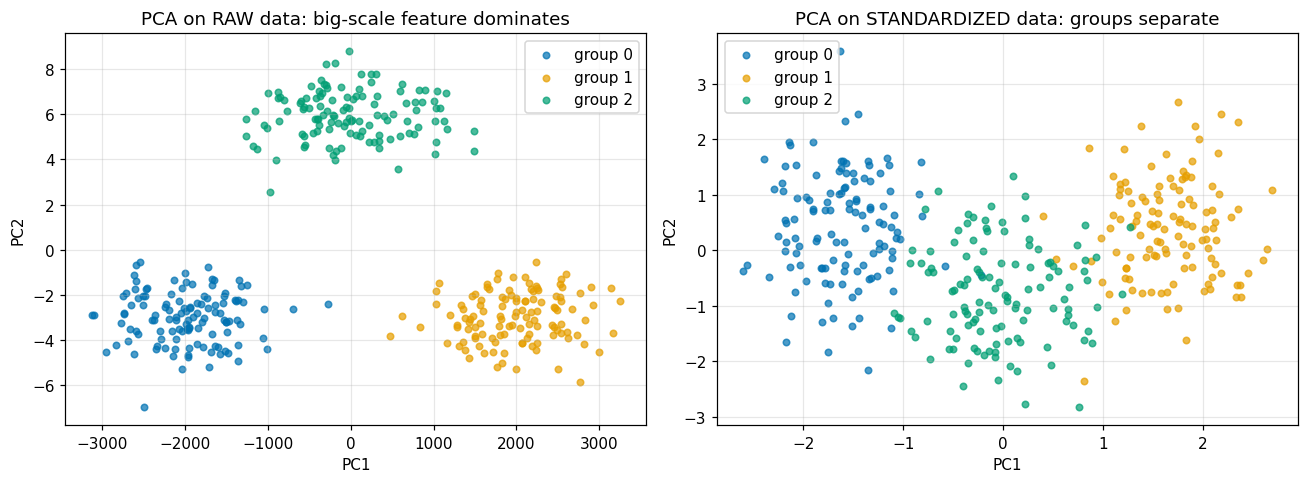

In [4]:
pca_raw = PCA(n_components=2).fit(X)
Xs = StandardScaler().fit_transform(X)
pca_std = PCA(n_components=2).fit(Xs)
Z_raw = pca_raw.transform(X)
Z_std = pca_std.transform(Xs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for g in np.unique(y_true):
    ax[0].scatter(Z_raw[y_true == g, 0], Z_raw[y_true == g, 1],
                  s=18, color=OKABE_ITO[g], alpha=0.7, label=f'group {g}')
    ax[1].scatter(Z_std[y_true == g, 0], Z_std[y_true == g, 1],
                  s=18, color=OKABE_ITO[g], alpha=0.7, label=f'group {g}')
ax[0].set_title('PCA on RAW data: big-scale feature dominates')
ax[1].set_title('PCA on STANDARDIZED data: groups separate')
for a in ax:
    a.set_xlabel('PC1'); a.set_ylabel('PC2'); a.legend()
plt.tight_layout(); plt.show()


## 4. Explained variance
Each principal component explains a fraction of total variance. The scree/cumulative plot helps decide how many components to keep. On the standardized data the first two components capture the blob structure.

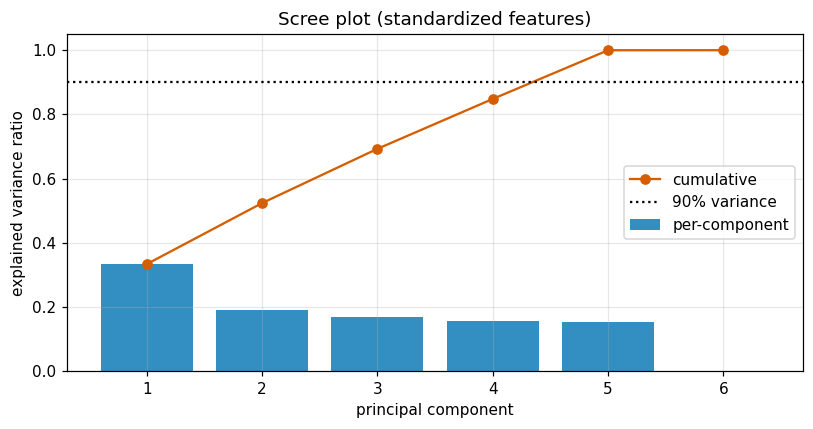

Cumulative variance by 2 components: 52.36%


In [5]:
pca_full = PCA().fit(Xs)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
fig, ax = plt.subplots(figsize=(7.5, 4))
comps = np.arange(1, len(evr) + 1)
ax.bar(comps, evr, color=OKABE_ITO[0], alpha=0.8, label='per-component')
ax.plot(comps, cum, marker='o', color=OKABE_ITO[3], label='cumulative')
ax.axhline(0.9, color=OKABE_ITO[7], ls=':', label='90% variance')
ax.set_xlabel('principal component'); ax.set_ylabel('explained variance ratio')
ax.set_title('Scree plot (standardized features)')
ax.legend(); plt.tight_layout(); plt.show()
print('Cumulative variance by 2 components:', f'{cum[1]:.2%}')


## 5. KMeans and choosing k
KMeans needs k in advance. We scan k, plotting **inertia** (elbow) and the **silhouette** score (higher is better). Both are computed on scaled data. The true data has 3 groups; we check whether the heuristics agree.

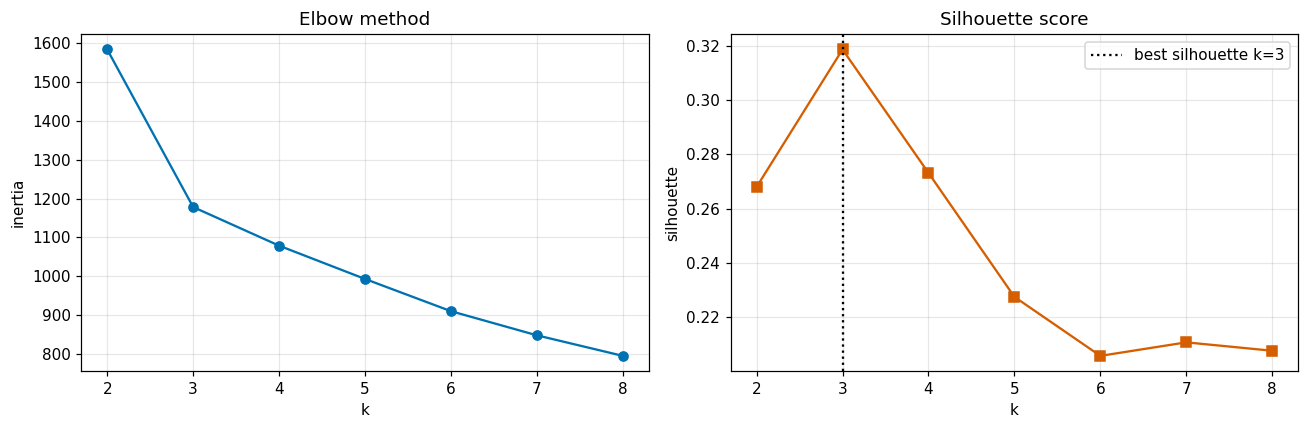

k with highest silhouette: 3


In [6]:
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xs, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertias, marker='o', color=OKABE_ITO[0])
ax[0].set_xlabel('k'); ax[0].set_ylabel('inertia'); ax[0].set_title('Elbow method')
ax[1].plot(list(ks), sils, marker='s', color=OKABE_ITO[3])
best_k = list(ks)[int(np.argmax(sils))]
ax[1].axvline(best_k, color=OKABE_ITO[7], ls=':', label=f'best silhouette k={best_k}')
ax[1].set_xlabel('k'); ax[1].set_ylabel('silhouette'); ax[1].set_title('Silhouette score')
ax[1].legend(); plt.tight_layout(); plt.show()
print(f'k with highest silhouette: {best_k}')


## 6. Final clustering and honest evaluation
We fit KMeans with the selected k on scaled data, visualize clusters in PCA space, and — because we happen to know the true groups — report the **Adjusted Rand Index** (ARI). In real unsupervised problems you would not have labels, which is exactly why cluster validity is hard.

Silhouette=0.319   Adjusted Rand Index vs. true groups=1.000 (1.0=perfect)


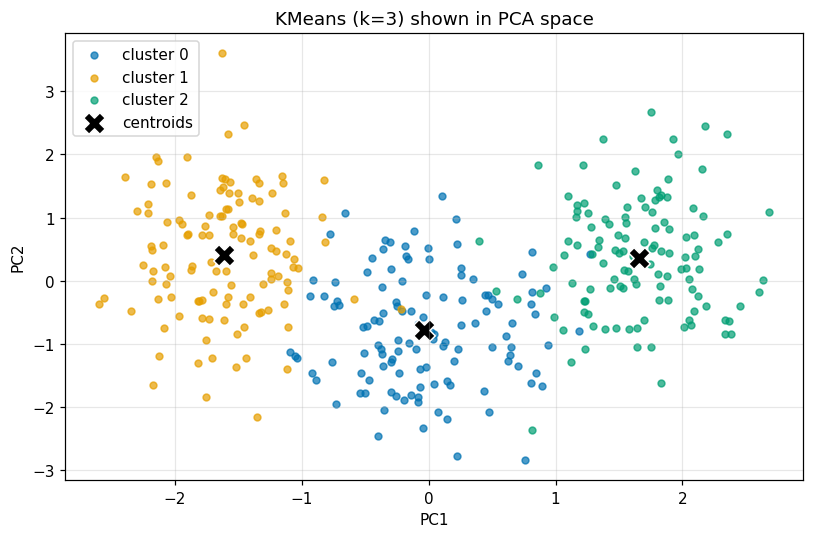

In [7]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(Xs)
ari = adjusted_rand_score(y_true, km.labels_)
sil = silhouette_score(Xs, km.labels_)
print(f'Silhouette={sil:.3f}   Adjusted Rand Index vs. true groups={ari:.3f} (1.0=perfect)')

centers_pca = pca_std.transform(km.cluster_centers_)
fig, ax = plt.subplots(figsize=(7.5, 5))
for c in range(best_k):
    ax.scatter(Z_std[km.labels_ == c, 0], Z_std[km.labels_ == c, 1],
               s=20, color=OKABE_ITO[c], alpha=0.7, label=f'cluster {c}')
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=200,
           color=OKABE_ITO[7], edgecolor='white', label='centroids')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'KMeans (k={best_k}) shown in PCA space')
ax.legend(); plt.tight_layout(); plt.show()


## Key takeaways and caveats

- **Scale before PCA/KMeans.** Both are variance/distance based; an unscaled large feature will dominate and hide real structure. Fit the scaler on training data in real pipelines.
- **PCA components are unsupervised mixtures of features.** They are great for compression/visualization but change the meaning of coordinates — do not read causal interpretation into them.
- **KMeans assumes roughly spherical, similarly sized clusters** and requires k up front. Elbow and silhouette are heuristics that can disagree; they do not prove a "true" number of clusters exists.
- **Cluster validity is genuinely hard without labels.** Metrics like silhouette measure geometric compactness, not correctness. Here we could use ARI only because we generated synthetic labels.
- Different seeds/initializations can give different clusterings; fix `random_state` and use `n_init` for stability, and treat clusters as hypotheses to validate, not conclusions.
